<a href="https://colab.research.google.com/github/eliasrbarbour/AAI614_eliasbarbour/blob/main/Week%203/Outlier_Detection_With_IQR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def iqr_outliers(series, k=1.5):
    """Detect outliers using the IQR (Tukey) method.
    Returns (mask, lower_bound, upper_bound, stats)."""
    s = pd.Series(series).dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (pd.Series(series) < lower) | (pd.Series(series) > upper)
    stats = {'Q1': q1, 'Q3': q3, 'IQR': iqr,
             'lower': lower, 'upper': upper,
             'n_outliers': int(mask.sum()),
             'pct': round(100 * mask.sum() / len(s), 2)}
    return mask, lower, upper, stats

In [4]:
nba = pd.read_csv("https://raw.githubusercontent.com/harmanani/AAI614/main/Week%202/nba.csv")
nba['Birthday'] = pd.to_datetime(nba['Birthday'], format='%m/%d/%y')
nba['Age'] = ((pd.Timestamp('2020-01-01') - nba['Birthday']).dt.days / 365.25).round(1)
print(nba.shape)
nba.head()

(450, 6)


,Name,Team,Position,Birthday,Salary,Age
0,Shake Milton,Philadelphia 76ers,SG,1996-09-26,1445697,23.3
1,Christian Wood,Detroit Pistons,PF,1995-09-27,1645357,24.3
2,PJ Washington,Charlotte Hornets,PF,1998-08-23,3831840,21.4
3,Derrick Rose,Detroit Pistons,PG,1988-10-04,7317074,31.2
4,Marial Shayok,Philadelphia 76ers,G,1995-07-26,79568,24.4


In [5]:
rows = []
for col in ['Salary', 'Age']:
    _, _, _, st = iqr_outliers(nba[col])
    rows.append({'Column': col, **{k: round(v, 2) if isinstance(v, float) else v
                                   for k, v in st.items()}})
pd.DataFrame(rows)

,Column,Q1,Q3,IQR,lower,upper,n_outliers,pct
0,Salary,1618520.0,10129574.25,8511054.25,-11148061.38,22896155.62,48,10.67
1,Age,22.9,28.80,5.90,14.05,37.65,3,0.67


In [6]:
mask, lo, hi, stats = iqr_outliers(nba['Salary'])
print(f"Upper fence: ${hi:,.0f}  |  {stats['n_outliers']} outliers ({stats['pct']}%)")
nba[mask].sort_values('Salary', ascending=False)[['Name','Team','Position','Salary','Age']].head(10)

Upper fence: $22,896,156  |  48 outliers (10.67%)


,Name,Team,Position,Salary,Age
205,Stephen Curry,Golden State Warriors,PG,40231758,31.8
38,Chris Paul,Oklahoma City Thunder,PG,38506482,34.7
219,Russell Westbrook,Houston Rockets,PG,38506482,31.1
251,John Wall,Washington Wizards,PG,38199000,29.3
264,James Harden,Houston Rockets,PG,38199000,30.3
408,LeBron James,Los Angeles Lakers,PF,37436858,35.0
95,Kevin Durant,Brooklyn Nets,PF,37199000,31.3
317,Blake Griffin,Detroit Pistons,PF,34449964,30.8
323,Kyle Lowry,Toronto Raptors,PG,33296296,33.8
397,Paul George,Los Angeles Clippers,SF,33005556,29.7


In [7]:
mask_age, lo_a, hi_a, stats_age = iqr_outliers(nba['Age'])
print(f"Upper fence: {hi_a:.1f} years  |  {stats_age['n_outliers']} outliers ({stats_age['pct']}%)")
nba[mask_age].sort_values('Age', ascending=False)[['Name','Team','Position','Age','Salary']]

Upper fence: 37.7 years  |  3 outliers (0.67%)


,Name,Team,Position,Age,Salary
98,Vince Carter,Atlanta Hawks,PF,42.9,2564753
196,Udonis Haslem,Miami Heat,C,39.6,2564753
262,Kyle Korver,Milwaukee Bucks,PF,38.8,6004753


In [8]:
ks = []
for k in [1.5, 2.0, 3.0]:
    _, _, _, st = iqr_outliers(nba['Salary'], k=k)
    ks.append({'k': k, 'outliers': st['n_outliers'], 'pct': st['pct'],
               'upper_fence': round(st['upper'])})
pd.DataFrame(ks)

,k,outliers,pct,upper_fence
0,1.5,48,10.67,22896156
1,2.0,34,7.56,27151683
2,3.0,7,1.56,35662737


In [9]:
z = (nba['Salary'] - nba['Salary'].mean()) / nba['Salary'].std()
comp = pd.DataFrame([
    {'Method': 'IQR k=1.5',     'Outliers': iqr_outliers(nba['Salary'], 1.5)[3]['n_outliers']},
    {'Method': 'IQR k=3.0',     'Outliers': iqr_outliers(nba['Salary'], 3.0)[3]['n_outliers']},
    {'Method': 'z-score |z|>2', 'Outliers': int((z.abs() > 2).sum())},
    {'Method': 'z-score |z|>3', 'Outliers': int((z.abs() > 3).sum())},
])
print(comp.to_string(index=False))
print(f"\nSalary skew: {nba['Salary'].skew():.2f}")

       Method  Outliers
    IQR k=1.5        48
    IQR k=3.0         7
z-score |z|>2        38
z-score |z|>3         7

Salary skew: 1.63


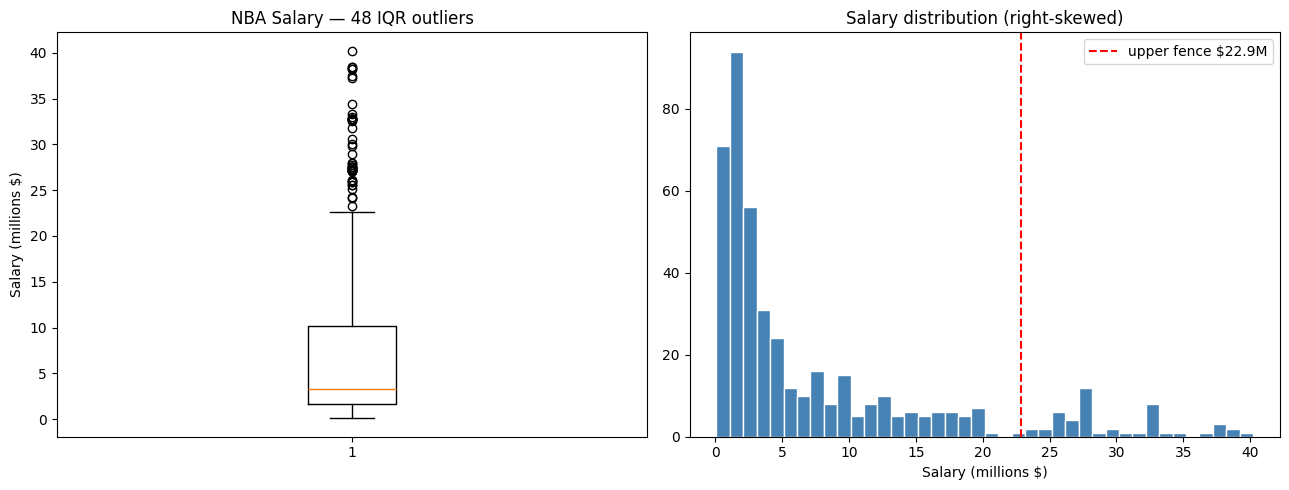

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].boxplot(nba['Salary'] / 1e6)
ax[0].set_title(f"NBA Salary — {stats['n_outliers']} IQR outliers")
ax[0].set_ylabel('Salary (millions $)')

ax[1].hist(nba['Salary'] / 1e6, bins=40, color='steelblue', edgecolor='white')
ax[1].axvline(hi / 1e6, color='red', ls='--', label=f'upper fence ${hi/1e6:.1f}M')
ax[1].set_title('Salary distribution (right-skewed)')
ax[1].set_xlabel('Salary (millions $)')
ax[1].legend()

plt.tight_layout()
plt.show()